In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functions import *

In [2]:
#Read in data file (see data_processing.ipynb for how this file is generated)
codes_and_CIs = pd.read_csv('combined_COPUS_CI_data.csv')
#The target variable is the effect size
target = codes_and_CIs['Effect Size'].to_numpy()
ES_variance = codes_and_CIs['Effect Size Variance'].to_numpy()

In [3]:
    ##plotting LOO predictions with error bars representing uncertainty across different fits
def LOO_plot(target, LOO_predictions_mean, LOO_predictions_std):
    x, y = target, LOO_predictions_mean
    plt.plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)

    where_low_error = np.where(LOO_predictions_std < .3)
    where_high_error = np.where(LOO_predictions_std >= .3)
    low_x, low_y = x[where_low_error], y[where_low_error]
    high_x, high_y = x[where_high_error], y[where_high_error]

    m, b = np.polyfit(x, y, 1)
    xi = np.linspace(np.min(x), np.max(x), 100)


    plt.scatter(low_x, low_y, label='Prediction uncertainty < .3', color='blue', alpha=0.7)
    plt.errorbar(low_x, low_y, yerr=LOO_predictions_std[where_low_error], fmt='o', color='blue', alpha=0.5)

    plt.scatter(high_x, high_y, label='Prediction uncertainty > .3', color='red', alpha=0.7)
    plt.errorbar(high_x, high_y, yerr=LOO_predictions_std[where_high_error], fmt='o', color='red', alpha=0.5)

    plt.xlabel(f'Measured Effect Size')
    plt.ylabel(f'Predicted Effect Size')
    plt.ylim(0, 3)
    #plt.title(f'Leave-One-Out Predictions vs Target')
    plt.legend()
    plt.savefig('Figs/LOO.png', dpi=300)
    plt.show()

    print(f'R^2: {np.corrcoef(x, y)[0, 1]**2:.3f}')
    print(f'Mean absolute error: {np.mean(np.abs(y-x)):.4f}')
    print('-----')
    print(f'R^2 removing high uncertainty: {np.corrcoef(low_x, low_y)[0, 1]**2:.3f}')
    print(f'MAE removing high uncertainty: {np.mean(np.abs(low_y-low_x)):.4f}')



### Maximum codes: Lec, CG, WG, OG, SQ

In [25]:
def AIC_weights(AICs):
    exp_AICs = np.exp(-0.5 * (AICs - np.min(AICs)))
    return exp_AICs / np.sum(exp_AICs)

In [33]:
(aic_weights @LOO_predictions).shape

(10, 69)

In [ ]:
#Maximum number of codes, choose CG over CQ

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
keepers, AICs, good_fits = feature_selection(data, target, its=1000,  prt = True, num_choose = 10, weights = 1/ES_variance)



LOO_predictions, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, weights = 1/ES_variance, bootstrap_n=100)

aic_weights = AIC_weights(AICs[good_fits])

LOO_feature_means = aic_weights.reshape(-1, 1, 1) * LOO_predictions

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

Iteration 1 finished with AIC 38.47


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 100 is different from 10)

In [57]:
aic_weights @ LOO_predictions

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 100 is different from 10)

In [54]:
LOO_feature_means = aic_weights.reshape( 1, 1, -1) @ LOO_predictions
print(LOO_feature_means.shape)

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 100 is different from 10)

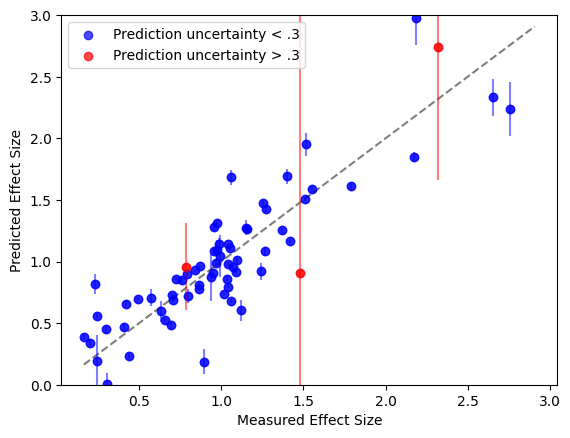

R^2: 0.757
Mean absolute error: 0.2409
-----
R^2 removing high uncertainty: 0.751
MAE removing high uncertainty: 0.2342


In [24]:


LOO_predictions_mean = np.mean(LOO_predictions[:1], axis=(0, 1))
LOO_predictions_std = np.std(LOO_predictions[:1], axis=(0, 1))/np.sqrt(10)
LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

In [9]:
AICs[good_fits]

array([22.16095552, 26.22948165, 26.29783669, 26.91166932, 27.19585166,
       27.23439043, 27.83388986, 27.99621333, 30.44515235, 32.16257228])

In [5]:
np.sum(keepers[good_fits], axis = 1)

array([35, 32, 26, 27, 27, 25, 29, 26, 30, 30])

## Same but choose CQ over CG

Iteration 1 finished with AIC 70.2
Iteration 1001 finished with AIC 80.52
Iteration 2001 finished with AIC 84.63
Iteration 3001 finished with AIC 78.24
Iteration 4001 finished with AIC 53.56
Iteration 5001 finished with AIC 77.06
Iteration 6001 finished with AIC 36.77
Iteration 7001 finished with AIC 73.93
Iteration 8001 finished with AIC 73.72
Iteration 9001 finished with AIC 128.47


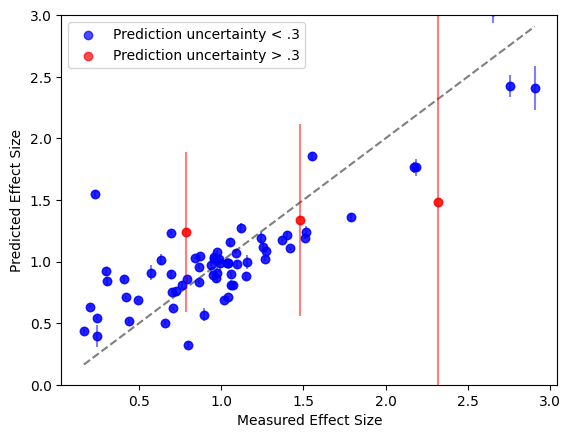

R^2: 0.686
Mean absolute error: 0.2431
-----
R^2 removing high uncertainty: 0.701
MAE removing high uncertainty: 0.2324


In [5]:
#Maximum number of codes, choose CQ over CG
#CG does way better


#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CQ', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, prt = True, num_choose = 10, weights = 1/ES_variance)

LOO_predictions, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, weights = 1/ES_variance, bootstrap_n=300)

LOO_feature_means = np.mean(LOO_predictions, axis=0)

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)


## Replace WG and OG with PQ

PQ necessarily happens alongside WG and OG

Iteration 1 finished with AIC 134.22
Iteration 1001 finished with AIC 141.19
Iteration 2001 finished with AIC 190.17
Iteration 3001 finished with AIC 181.34
Iteration 4001 finished with AIC 155.14
Iteration 5001 finished with AIC 127.6
Iteration 6001 finished with AIC 151.01
Iteration 7001 finished with AIC 177.42
Iteration 8001 finished with AIC 135.1
Iteration 9001 finished with AIC 128.49


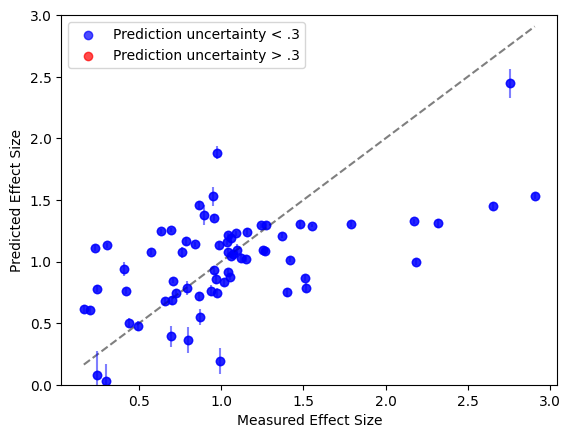

R^2: 0.327
Mean absolute error: 0.3521
-----
R^2 removing high uncertainty: 0.327
MAE removing high uncertainty: 0.3521


In [6]:
#replace OG and WG with PQ
#does way worse

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'PQ', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, prt = True, num_choose = 10, weights = 1/ES_variance)

LOO_predictions, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300, weights = 1/ES_variance)

LOO_feature_means = np.mean(LOO_predictions, axis=0)

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

## Remove Lec: CG, WG, OG,  SQ (only student vars)

Iteration 1 finished with AIC 61.81
Iteration 1001 finished with AIC 77.51
Iteration 2001 finished with AIC 56.92
Iteration 3001 finished with AIC 85.4
Iteration 4001 finished with AIC 62.62
Iteration 5001 finished with AIC 54.8
Iteration 6001 finished with AIC 90.26
Iteration 7001 finished with AIC 105.56
Iteration 8001 finished with AIC 81.2
Iteration 9001 finished with AIC 79.14


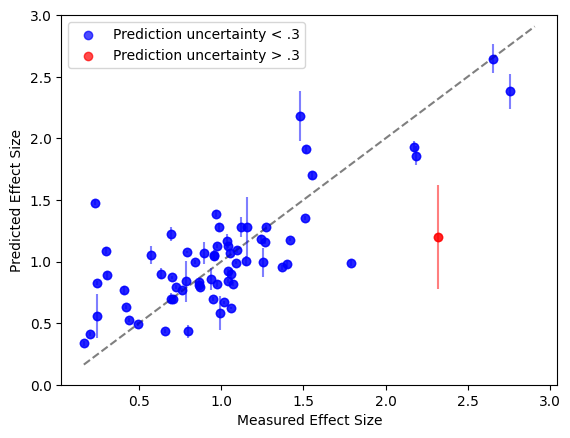

R^2: 0.626
Mean absolute error: 0.2618
-----
R^2 removing high uncertainty: 0.662
MAE removing high uncertainty: 0.2492


In [7]:
#remove lec

#these will be input features for the model
data = codes_and_CIs[[ 'WG', 'CG', 'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, prt = True, num_choose = 10, weights = 1/ES_variance)

LOO_predictions, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300, weights = 1/ES_variance)

LOO_feature_means = np.mean(LOO_predictions, axis=0)

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

## Remove OG: Lec, CG, WG, SQ (Previous)

Iteration 1 finished with AIC 38.27
Iteration 1001 finished with AIC 45.59
Iteration 2001 finished with AIC 89.97
Iteration 3001 finished with AIC 37.73
Iteration 4001 finished with AIC 70.54
Iteration 5001 finished with AIC 40.8
Iteration 6001 finished with AIC 50.71
Iteration 7001 finished with AIC 49.35
Iteration 8001 finished with AIC 90.77
Iteration 9001 finished with AIC 48.95


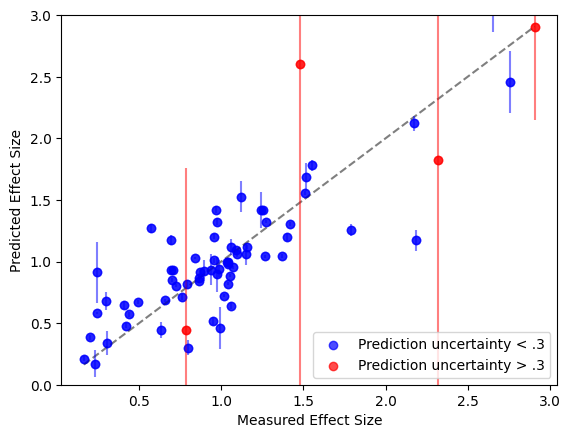

R^2: 0.715
Mean absolute error: 0.2244
-----
R^2 removing high uncertainty: 0.702
MAE removing high uncertainty: 0.2078


In [8]:
#remove OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, prt = True, num_choose = 10, weights = 1/ES_variance)

LOO_predictions, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300, weights = 1/ES_variance)

LOO_feature_means = np.mean(LOO_predictions, axis=0)

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

## Remove WG: Lec, CG, OG, SQ

Iteration 1 finished with AIC 138.61
Iteration 1001 finished with AIC 140.39
Iteration 2001 finished with AIC 123.44
Iteration 3001 finished with AIC 117.74
Iteration 4001 finished with AIC 164.66
Iteration 5001 finished with AIC 143.12
Iteration 6001 finished with AIC 134.54
Iteration 7001 finished with AIC 134.9
Iteration 8001 finished with AIC 150.25
Iteration 9001 finished with AIC 142.79


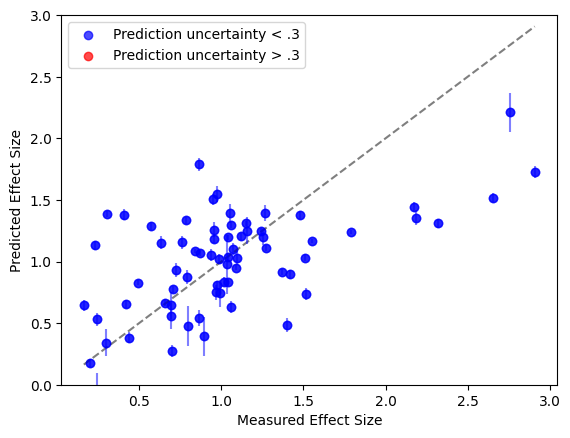

R^2: 0.329
Mean absolute error: 0.3640
-----
R^2 removing high uncertainty: 0.329
MAE removing high uncertainty: 0.3640


In [9]:
#remove WG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, prt = True, num_choose = 10, weights = 1/ES_variance)

LOO_predictions, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300, weights = 1/ES_variance)

LOO_feature_means = np.mean(LOO_predictions, axis=0)

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

## Remove SQ: Lec, CG, WG, OG

Iteration 1 finished with AIC 96.48
Iteration 1001 finished with AIC 76.84
Iteration 2001 finished with AIC 83.19
Iteration 3001 finished with AIC 81.74
Iteration 4001 finished with AIC 83.86
Iteration 5001 finished with AIC 108.85
Iteration 6001 finished with AIC 122.64
Iteration 7001 finished with AIC 84.68
Iteration 8001 finished with AIC 102.06
Iteration 9001 finished with AIC 84.83


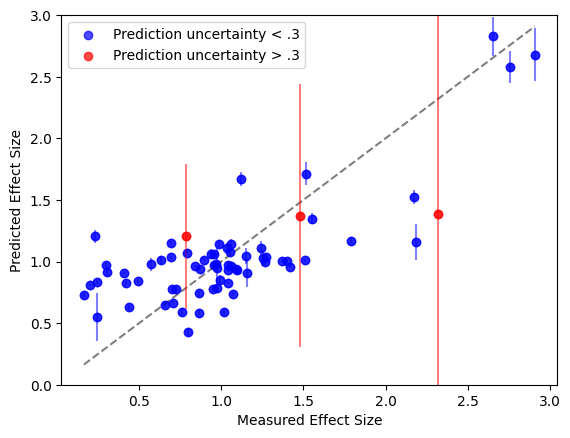

R^2: 0.585
Mean absolute error: 0.2898
-----
R^2 removing high uncertainty: 0.598
MAE removing high uncertainty: 0.2809


In [10]:
#remove SQ

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG',  ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, prt = True, num_choose = 10, weights = 1/ES_variance)

LOO_predictions, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300, weights = 1/ES_variance)

LOO_feature_means = np.mean(LOO_predictions, axis=0)

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

## Combine WG and OG

Iteration 1 finished with AIC 138.86
Iteration 1001 finished with AIC 127.16
Iteration 2001 finished with AIC 137.11
Iteration 3001 finished with AIC 96.44
Iteration 4001 finished with AIC 148.79
Iteration 5001 finished with AIC 102.65
Iteration 6001 finished with AIC 102.5
Iteration 7001 finished with AIC 179.19
Iteration 8001 finished with AIC 143.04
Iteration 9001 finished with AIC 162.73


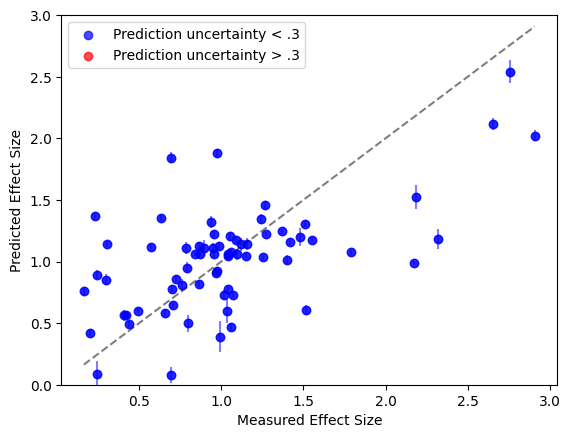

R^2: 0.374
Mean absolute error: 0.3370
-----
R^2 removing high uncertainty: 0.374
MAE removing high uncertainty: 0.3370


In [11]:
#combine WG and OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ' ]].to_numpy()
data[:, 2] = data[:, 2] + data[:, 3]
data = data[:, [0, 1, 2, 4]] #remove OG
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, prt = True, num_choose = 10, weights = 1/ES_variance)

LOO_predictions, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300, weights = 1/ES_variance)

LOO_feature_means = np.mean(LOO_predictions, axis=0)

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

Iteration 1 finished with AIC 88.27
Iteration 1001 finished with AIC 150.53
Iteration 2001 finished with AIC 82.42
Iteration 3001 finished with AIC 113.71
Iteration 4001 finished with AIC 110.75
Iteration 5001 finished with AIC 115.84
Iteration 6001 finished with AIC 109.73
Iteration 7001 finished with AIC 138.4
Iteration 8001 finished with AIC 135.17
Iteration 9001 finished with AIC 156.9


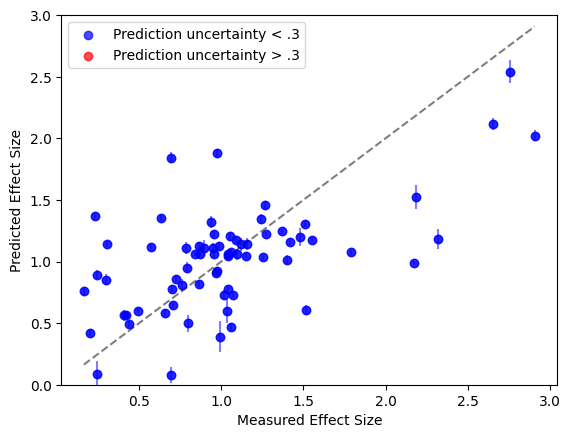

R^2: 0.374
Mean absolute error: 0.3370
-----
R^2 removing high uncertainty: 0.374
MAE removing high uncertainty: 0.3370


array([68.41181554, 69.58725456, 69.92797609, 71.68336164, 72.29203821,
       72.33873666, 72.65029999, 73.13186576, 73.32599612, 73.53948653])

In [12]:
#combine CG and OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ' ]].to_numpy()
data[:, 1] = data[:, 1] + data[:, 3]
data = data[:, [0, 1, 2, 4]] #remove OG
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000,  prt = True, num_choose = 10, weights = 1/ES_variance)

LOO_predictions, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300, weights = 1/ES_variance)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)
AICs[good_fits]

## Combine all group work

Iteration 1 finished with AIC 105.24
Iteration 1001 finished with AIC 114.38
Iteration 2001 finished with AIC 104.39
Iteration 3001 finished with AIC 104.85
Iteration 4001 finished with AIC 120.99
Iteration 5001 finished with AIC 96.4
Iteration 6001 finished with AIC 118.28
Iteration 7001 finished with AIC 104.62
Iteration 8001 finished with AIC 118.34
Iteration 9001 finished with AIC 106.34


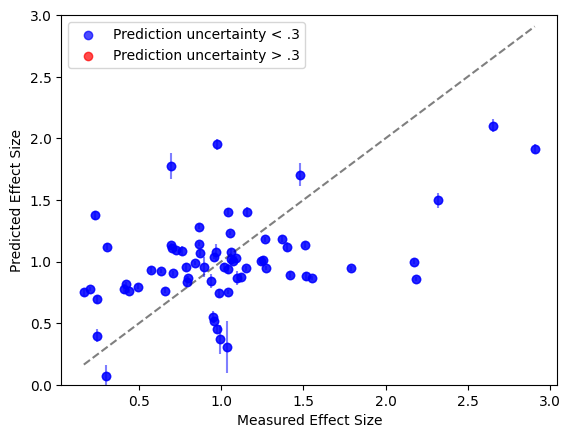

R^2: 0.318
Mean absolute error: 0.3860
-----
R^2 removing high uncertainty: 0.318
MAE removing high uncertainty: 0.3860


In [13]:
#combine all group work

#combine WG and OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ' ]].to_numpy()
data[:, 2] = data[:, 2] + data[:, 3] + data[:, 1]
data = data[:, [0,  2, 4]] #remove OG
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, prt = True, num_choose = 10, weights = 1/ES_variance)

LOO_predictions, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300, weights = 1/ES_variance)

LOO_feature_means = np.mean(LOO_predictions, axis=0)

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

# Model Complexity

In [14]:
#up to third order terms

def add_cross_terms_3(data):
    ## this functions adds polynomial and cross terms to the data
        
    pts, features = data.shape
    #
    cross_factors = (data[:, :features].reshape(pts, 1, features) *data[:, :features].reshape(pts, features, 1))#.reshape(pts, features * features)
    #keep only upper triangle

    #second order terms
    cross_factors = cross_factors[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]
    cross_factors = np.hstack((cross_factors, data**2))

    #third order terms
    cross_21 = (data.reshape(pts, 1, features)**2 * data.reshape(pts, features, 1))
    cross_12 = (data.reshape(pts, 1, features) * data.reshape(pts, features, 1)**2)


    cross_factors = np.hstack((cross_factors, cross_21[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))
    cross_factors = np.hstack((cross_factors, cross_12[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))


    data = np.hstack((data, cross_factors))

    

    data = np.hstack((data, data[:, :1]*data[:, 1:2]* data[:, 2:3]))  # interaction term for first three features
    if features >= 4:
        data = np.hstack((data, data[:, :1]*data[:, 1:2]* data[:, 3:4]))  # interaction term for first second and fourth features
        data = np.hstack((data, data[:, :1]*data[:, 2:3]* data[:, 3:4]))  # interaction term for first third and fourth features
        data = np.hstack((data, data[:, 1:2] * data[:, 2:3] * data[:, 3:4]))  # interaction term for second third and fourth features
    
    #######################
    if features >= 5:
        data = np.hstack((data, data[:, :1] * data[:, 1:2] * data[:, 4:5]))  # interaction term for first second and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 2:3] * data[:, 4:5]))  # interaction term for first third and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 3:4] * data[:, 4:5]))  # interaction term for first fourth and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:,  2:3] * data[:, 4:5]))  # interaction term for second third and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:, 3:4] * data[:, 4:5]))  # interaction term for second fourth and fifth features
        data = np.hstack((data, data[:, 2:3] * data[:, 3:4] * data[:, 4:5]))  # interaction term for third fourth and fifth features
        ########################
    data = np.hstack((data, data[:, :4]**3))  #third order ter

    data = np.hstack((data, np.ones((data.shape[0], 1))))  # add bias term
    return data


Iteration 1 finished with AIC 122.09
Iteration 1001 finished with AIC 59.54
Iteration 2001 finished with AIC 96.47
Iteration 3001 finished with AIC 76.4
Iteration 4001 finished with AIC 100.88
Iteration 5001 finished with AIC 75.51
Iteration 6001 finished with AIC 92.93
Iteration 7001 finished with AIC 90.53
Iteration 8001 finished with AIC 172.78
Iteration 9001 finished with AIC 86.96


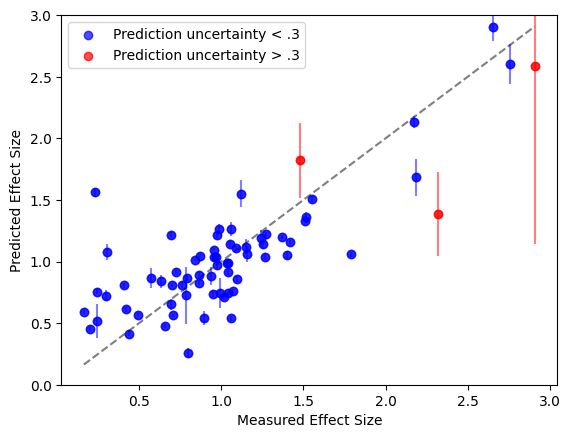

R^2: 0.661
Mean absolute error: 0.2439
-----
R^2 removing high uncertainty: 0.624
MAE removing high uncertainty: 0.2307


In [15]:
#up to thrid order
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_3(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, prt = True, num_choose = 10, weights = 1/ES_variance)

LOO_predictions, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300, weights = 1/ES_variance)

LOO_feature_means = np.mean(LOO_predictions, axis=0)

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

In [16]:
#up to second order terms

def add_cross_terms_2(data):
    ## this functions adds polynomial and cross terms to the data
        
    pts, features = data.shape
    #
    cross_factors = (data[:, :features].reshape(pts, 1, features) *data[:, :features].reshape(pts, features, 1))#.reshape(pts, features * features)
    #keep only upper triangle

    #second order terms
    cross_factors = cross_factors[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]
    cross_factors = np.hstack((cross_factors, data**2))


    data = np.hstack((data, cross_factors))

    data = np.hstack((data, np.ones((data.shape[0], 1))))  # add bias term
    return data


Iteration 1 finished with AIC 78.13
Iteration 1001 finished with AIC 74.91
Iteration 2001 finished with AIC 71.47
Iteration 3001 finished with AIC 63.87
Iteration 4001 finished with AIC 70.06
Iteration 5001 finished with AIC 64.07
Iteration 6001 finished with AIC 65.22
Iteration 7001 finished with AIC 90.38
Iteration 8001 finished with AIC 78.79
Iteration 9001 finished with AIC 67.88


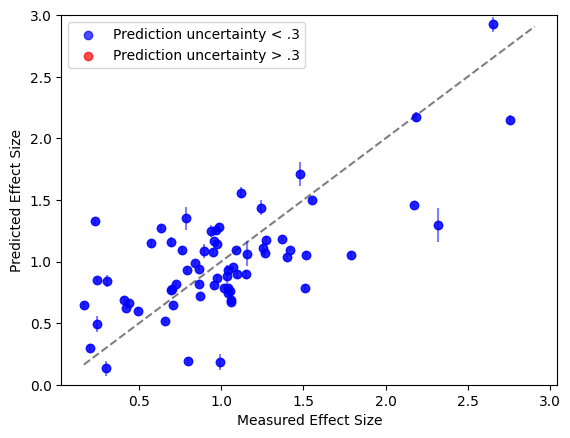

R^2: 0.578
Mean absolute error: 0.3008
-----
R^2 removing high uncertainty: 0.578
MAE removing high uncertainty: 0.3008


In [17]:
#add in PQ, up to second
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', 'PQ' ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_2(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, prt = True, num_choose = 10, weights = 1/ES_variance)

LOO_predictions, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300, weights = 1/ES_variance)

LOO_feature_means = np.mean(LOO_predictions, axis=0)

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

Iteration 1 finished with AIC 75.56
Iteration 1001 finished with AIC 74.72
Iteration 2001 finished with AIC 60.18
Iteration 3001 finished with AIC 69.83
Iteration 4001 finished with AIC 50.16
Iteration 5001 finished with AIC 62.66
Iteration 6001 finished with AIC 62.31
Iteration 7001 finished with AIC 72.62
Iteration 8001 finished with AIC 76.95
Iteration 9001 finished with AIC 56.19


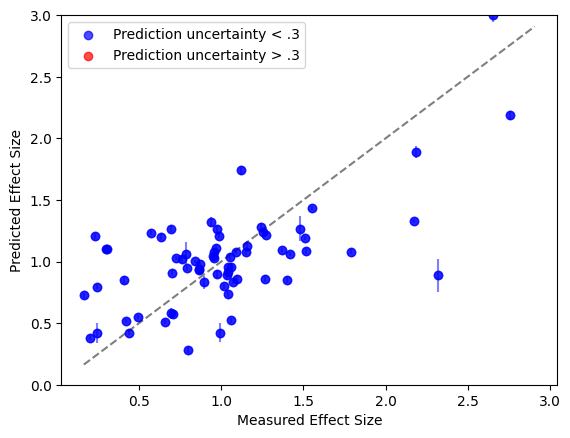

R^2: 0.515
Mean absolute error: 0.3036
-----
R^2 removing high uncertainty: 0.515
MAE removing high uncertainty: 0.3036


In [18]:
#up to second order
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_2(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, prt = True, num_choose = 10, weights = 1/ES_variance)

LOO_predictions, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300, weights = 1/ES_variance)

LOO_feature_means = np.mean(LOO_predictions, axis=0)

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

Iteration 1 finished with AIC 120.91
Iteration 1001 finished with AIC 121.29
Iteration 2001 finished with AIC 115.69
Iteration 3001 finished with AIC 120.89
Iteration 4001 finished with AIC 118.07
Iteration 5001 finished with AIC 119.93
Iteration 6001 finished with AIC 102.81
Iteration 7001 finished with AIC 121.62
Iteration 8001 finished with AIC 118.18
Iteration 9001 finished with AIC 119.93


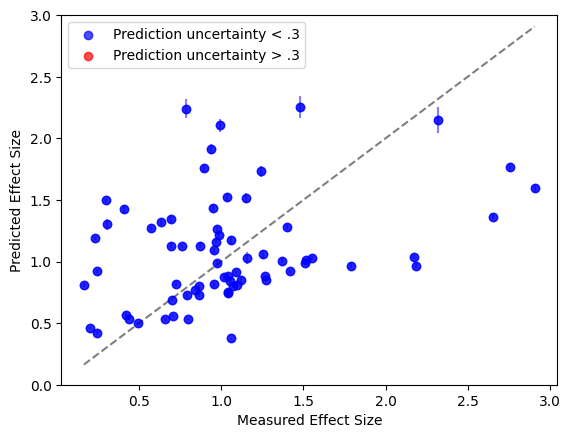

R^2: 0.113
Mean absolute error: 0.4610
-----
R^2 removing high uncertainty: 0.113
MAE removing high uncertainty: 0.4610


In [19]:
#first order
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = data

keepers, AICs, good_fits = feature_selection(data, target, its=10000, prt = True, num_choose = 10, weights = 1/ES_variance)

LOO_predictions, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300, weights = 1/ES_variance)

LOO_feature_means = np.mean(LOO_predictions, axis=0)

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

In [20]:
#no 1st order terms, get rid of colinearity
def add_cross_terms_no1(data):
    ## this functions adds polynomial and cross terms to the data
        
    pts, features = data.shape
    #
    cross_factors = (data[:, :features].reshape(pts, 1, features) *data[:, :features].reshape(pts, features, 1))#.reshape(pts, features * features)
    #keep only upper triangle

    #second order terms
    cross_factors = cross_factors[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]
    cross_factors = np.hstack((cross_factors, data**2))

    #third order terms
    cross_21 = (data.reshape(pts, 1, features)**2 * data.reshape(pts, features, 1))
    cross_12 = (data.reshape(pts, 1, features) * data.reshape(pts, features, 1)**2)


    cross_factors = np.hstack((cross_factors, cross_21[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))
    cross_factors = np.hstack((cross_factors, cross_12[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))

    data = np.hstack((cross_factors, data[:, :1]*data[:, 1:2]* data[:, 2:3]))  # interaction term for first three features
    if features >= 4:
        data = np.hstack((data, data[:, :1]*data[:, 1:2]* data[:, 3:4]))  # interaction term for first second and fourth features
        data = np.hstack((data, data[:, :1]*data[:, 2:3]* data[:, 3:4]))  # interaction term for first third and fourth features
        data = np.hstack((data, data[:, 1:2] * data[:, 2:3] * data[:, 3:4]))  # interaction term for second third and fourth features
    
    #######################
    if features >= 5:
        data = np.hstack((data, data[:, :1] * data[:, 1:2] * data[:, 4:5]))  # interaction term for first second and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 2:3] * data[:, 4:5]))  # interaction term for first third and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 3:4] * data[:, 4:5]))  # interaction term for first fourth and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:,  2:3] * data[:, 4:5]))  # interaction term for second third and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:, 3:4] * data[:, 4:5]))  # interaction term for second fourth and fifth features
        data = np.hstack((data, data[:, 2:3] * data[:, 3:4] * data[:, 4:5]))  # interaction term for third fourth and fifth features
        ########################
    data = np.hstack((data, data[:, :4]**3))  #third order terms

    
    #fourth order terms
    data = np.hstack((data, data[:, :4]**4))

    data = np.hstack((data, np.ones((data.shape[0], 1))))  # add bias term
    return data


Iteration 1 finished with AIC 83.3
Iteration 1001 finished with AIC 119.66
Iteration 2001 finished with AIC 65.03
Iteration 3001 finished with AIC 189.1
Iteration 4001 finished with AIC 70.33
Iteration 5001 finished with AIC 80.49
Iteration 6001 finished with AIC 61.96
Iteration 7001 finished with AIC 57.49
Iteration 8001 finished with AIC 102.39
Iteration 9001 finished with AIC 189.6


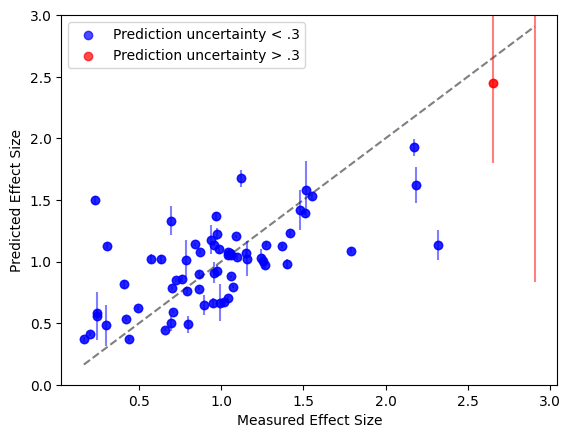

R^2: 0.027
Mean absolute error: 0.5901
-----
R^2 removing high uncertainty: 0.412
MAE removing high uncertainty: 0.2551


In [21]:
#no first order

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_no1(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, prt = True, num_choose = 10, weights = 1/ES_variance)

LOO_predictions, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300, weights = 1/ES_variance)

LOO_feature_means = np.mean(LOO_predictions, axis=0)

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)